In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import c5g7
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, eig

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = c5g7()

In [3]:
# Create quarter circle NURBS surface
radius = 0.54 # cm
pitch = 1.26 # cm
c0 = cad.circle(radius=radius, angle=np.pi / 2)
c1 = c0.slice(0, 0, 0.5)
c2 = c0.slice(0, 0.5, 1)
l0 = cad.line(p0=(0, 0), p1=(0, 0))
fuel1 = cad.ruled(l0, c1)
fuel2 = cad.ruled(l0, c2)

# Create water patch
l1 = cad.line(p0=(pitch / 2, 0), p1=(pitch / 2, pitch / 2))
l2 = cad.line(p0=(pitch / 2, pitch / 2), p1=(0, pitch / 2))
mod1 = cad.ruled(c1, l1)
mod2 = cad.ruled(c2, l2)

# NURBS surfaces
patches = {}
patches[fuel1] = "UO2"
patches[fuel2] = "UO2"
patches[mod1] = "Water"
patches[mod2] = "Water"

# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 6, 2)

# Finalize mesh
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

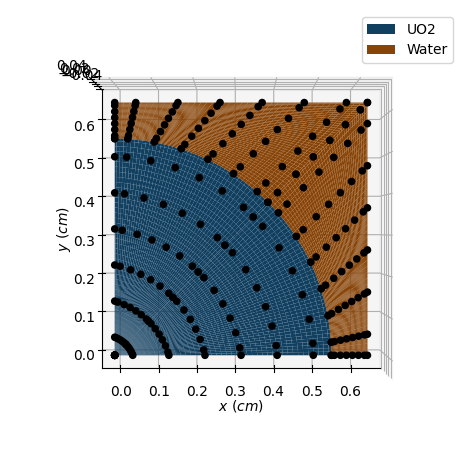

In [4]:
# Plot final mesh
ax = mesh.plot()
ax.view_init(90, -90, 0)
plt.legend()
plt.tight_layout()
plt.savefig("./figs/pincell.png", dpi=300)
plt.show()

In [5]:
print("Assemble system in COOrdinate format")
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
H_m, S_m, F_m, B_in_m, B_out_m = assembler.build()

# Create operators in TT format
print("\nAssemble system in TT format")
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H_tt, S_tt, F_tt, B_in_tt, B_out_tt = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info.csv")

Assemble system in COOrdinate format
Discretization: N = 1024, G = 7, P = 4, A = 8, B = 8
Assembling Patch 1
Step            Shape                     Compression  Elapsed Time (s)
H               1835008,1835008            135456.18        3.40
S               1,1792,1792                    34.72        3.41
F               1792,1792                      33.07        3.42
B_in            1835008,1835008           3030302.86        3.69
B_out           1835008,1835008           3055188.27        3.94
Assembling Patch 2
Step            Shape                     Compression  Elapsed Time (s)
H               1835008,1835008            135456.18        7.43
S               1,1792,1792                    34.72        7.43
F               1792,1792                      33.07        7.44
B_in            1835008,1835008           2995319.54        7.68
B_out           1835008,1835008           3028356.99        7.90
Assembling Patch 3
Step            Shape                     Compression  Elap

In [6]:
k, psi = eig(
    LHS=LinearOperator([H_tt, B_out_m - B_in_m, -S_tt], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F_tt], N=assembler.N, M=assembler.M),
    tols=1e-8,
    max_iters=500,
    device=0,
    linear_solver_opts={
        "max_iterations": 100,
        "threshold": 1e-10,
        "resets": 10,
    },
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration
-- (0): k = 0.61432497, Angular Flux L2-Error = 2.11655865, Elapsed Time = 68.196
-- (1): k = 1.01439524, Angular Flux L2-Error = 0.32050103, Elapsed Time = 137.443
-- (2): k = 1.22383094, Angular Flux L2-Error = 0.07661425, Elapsed Time = 206.837
-- (3): k = 1.29481696, Angular Flux L2-Error = 0.0214867, Elapsed Time = 276.757
-- (4): k = 1.31653692, Angular Flux L2-Error = 0.00628622, Elapsed Time = 347.587
-- (5): k = 1.32287323, Angular Flux L2-Error = 0.00200086, Elapsed Time = 415.958
-- (6): k = 1.32468241, Angular Flux L2-Error = 0.00082915, Elapsed Time = 485.211
-- (7): k = 1.32519095, Angular Flux L2-Error = 0.00047982, Elapsed Time = 557.197
-- (8): k = 1.32533111, Angular Flux L2-Error = 0.00032641, Elapsed Time = 628.408
-- (9): k = 1.32537039, Angular Flux L2-Error = 0.00023602, Elapsed Time = 697.821
-- (10): k = 1.32538222, Angular Flux L2-Error = 0.00017681, Elapsed Time = 769.124
-- (11): k = 1.32538626, Angular Flux L2-Error = 0.00013484, El

In [7]:
# Get OpenMC solution
k_mc = [1.325593, 0.000032]
phi_mc = np.load("./openmc/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

# Calculate eigenvalue error
print("keff error: {} +/- {} pcm".format((k - k_mc[0]) * 1e5, k_mc[1]))

keff error: -20.326483490573644 +/- 3.2e-05 pcm


In [8]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    fig = mesh.plot(backend="plotly")
    fig.update_layout(scene={"zaxis_title": f"Scalar Flux (g = {g + 1})"})
    fig.write_html(f"./figs/phi_{g + 1}.html")
    del fig

# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)

Scalar flux Relative L2-error (g = 1): 0.0047363071397465905
Scalar flux Relative L2-error (g = 2): 0.0005513131390809112
Scalar flux Relative L2-error (g = 3): 0.000564701563466467
Scalar flux Relative L2-error (g = 4): 0.0006412591175093287
Scalar flux Relative L2-error (g = 5): 0.0006776590815958158
Scalar flux Relative L2-error (g = 6): 0.000645229118549479
Scalar flux Relative L2-error (g = 7): 0.000658863046866332
Total scalar flux Relative L2-error: 0.0018419079468791546
